## Iteration 2
From the previous notebook results it is clear that the model weights are not at all learning so the problem is rather with the weights so next step is first train the model on MSE for some iterations and then train it on CVar for better results.One more improvement we can do is Normalising the prize value as neural networks will work well when normalised we are gonna normalise in this way $$S_{normalised}=S/K$$.

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# Set the path to the file you'd like to load
file_path = "20260205_option_minute_prices_expiry.csv"

# Load the latest version
df_feb05 = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "nikileshthotamsetty2/stock-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

display(df_feb05.head())

,date,minute_end,symbol,last_trade_price
0,20260205,91600,NIFTY26FEBFUT,2578540.0
1,20260205,91600,NIFTY2621025600CE,23115.0
2,20260205,91600,NIFTY2621025650CE,19995.0
3,20260205,91600,NIFTY2621025700CE,17140.0
4,20260205,91600,NIFTY2621025750CE,14535.0


In [ ]:
import numpy as np
import pandas as pd

# Filter for 11 AM (11:00:00)
# Ensure 'minute_end' is treated as an integer for filtering
filtered_df = df_feb05[df_feb05['minute_end'] == 110000].copy()

# Extract Future Price
futures_row = filtered_df[filtered_df['symbol'].str.contains('FUT')]
if not futures_row.empty:
    S_paisa = futures_row['last_trade_price'].iloc[0]
    S = S_paisa # Convert paisa to rupees
    print(f"Future Price (S) at 11 AM (in rupees): {S}")
else:
    S = None
    print("Future price not found at 11 AM. Cannot calculate Greeks or IV without S.")

# Filter out the futures row from the options data
options_df = filtered_df[~filtered_df['symbol'].str.contains('FUT')].copy()

# Parse option symbols to get Strike Price and Option Type (CE/PE)
def parse_symbol(symbol):
    option_type = None
    strike = None

    if 'CE' in symbol:
        option_type = 'call'
        strike_part = symbol.split('CE')[0]
        # Extract last 5 digits from the numeric part before 'CE'
        digits_only = ''.join(filter(str.isdigit, strike_part))
        if len(digits_only) >= 5:
            strike = float(digits_only[-5:])
    elif 'PE' in symbol:
        option_type = 'put'
        strike_part = symbol.split('PE')[0]
        # Extract last 5 digits from the numeric part before 'PE'
        digits_only = ''.join(filter(str.isdigit, strike_part))
        if len(digits_only) >= 5:
            strike = float(digits_only[-5:])

    return strike, option_type

options_df[['strike', 'option_type']] = options_df['symbol'].apply(lambda x: pd.Series(parse_symbol(x)))

# Convert strike and last_trade_price from paisa to rupees
options_df['strike'] = options_df['strike'] * 100.0
options_df['last_trade_price'] = options_df['last_trade_price']

# Drop rows where parsing failed or strike is None
options_df.dropna(subset=['strike', 'option_type'], inplace=True)

# Combine 'date' (e.g., 20260205) and 'minute_end' (e.g., 110000) into a single datetime object
options_df['observation_datetime_str'] = options_df['date'].astype(str) + options_df['minute_end'].astype(str).str.zfill(6)
options_df['observation_datetime'] = pd.to_datetime(options_df['observation_datetime_str'], format='%Y%m%d%H%M%S')

# User specified expiration date and time: 0502 (Feb 5th) at 3:30 PM (15:30)
expiration_date = pd.to_datetime('2026-02-05 15:30:00')

# Calculate Time to Expiration (T) in years
# dt.total_seconds() gives seconds, then convert to years
options_df['T'] = (expiration_date - options_df['observation_datetime']).dt.total_seconds() / (365.25 * 24 * 3600)

# Assume a risk-free rate (r)
r = 0.05 # 5%

print(f"Number of options at 11 AM: {len(options_df)}")
display(options_df.head())

Future Price (S) at 11 AM (in rupees): 2571510.0
Number of options at 11 AM: 22


,date,minute_end,symbol,last_trade_price,strike,option_type,observation_datetime_str,observation_datetime,T
2393,20260205,110000,NIFTY2621025600CE,16790.0,2560000.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2394,20260205,110000,NIFTY2621025650CE,14115.0,2565000.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2395,20260205,110000,NIFTY2621025700CE,11770.0,2570000.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2396,20260205,110000,NIFTY2621025750CE,9725.0,2575000.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2397,20260205,110000,NIFTY2621025800CE,7990.0,2580000.0,call,20260205110000,2026-02-05 11:00:00,0.000513


In [ ]:
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type):
    if T <= 0: # Handle zero or negative time to expiration
        if option_type == 'call':
            return max(0, S - K), 0, 0, 0
        else:
            return max(0, K - S), 0, 0, 0

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price, delta, gamma, theta

print("Black-Scholes function defined.")

Black-Scholes function defined.


In [ ]:
def implied_volatility(observed_price, S, K, T, r, option_type, tol=1e-5, max_iter=100, verbose=False):
    low_vol = 0.001
    high_vol = 5.0 # Max reasonable volatility

    for i in range(max_iter):
        mid_vol = (low_vol + high_vol) / 2

        if verbose:
            print(f"Iteration {i+1}: low_vol={low_vol:.4f}, high_vol={high_vol:.4f}, mid_vol={mid_vol:.4f}")

        if mid_vol < 1e-6: # Avoid division by zero or extremely small sigma
            mid_vol = 1e-6

        bs_price, _, _, _ = black_scholes(S, K, T, r, mid_vol, option_type)

        if verbose:
            print(f"  BS Price: {bs_price:.2f}, Observed Price: {observed_price:.2f}, Diff: {bs_price - observed_price:.2f}")

        # Handle cases where BS price is very close to observed price
        if abs(bs_price - observed_price) < tol:
            return mid_vol

        if bs_price < observed_price:
            low_vol = mid_vol
        else:
            high_vol = mid_vol

        if (high_vol - low_vol) < tol:
            if verbose:
                print(f"Converged within tolerance at iteration {i+1}.")
            return mid_vol # Converged within tolerance

    if verbose:
        print("Max iterations reached, returning best guess.")
    return mid_vol # Return the best guess if max_iter reached

print("Implied Volatility solver defined.")

Implied Volatility solver defined.


In [ ]:
if S is not None:
    options_df['implied_volatility'] = options_df.apply(
        lambda row: implied_volatility(row['last_trade_price'], S, row['strike'], row['T'], r, row['option_type'], verbose=True)
        if row['T'] > 0 else 0, axis=1
    )
else:
    options_df['implied_volatility'] = np.nan
    print("Cannot calculate implied volatility as future price (S) is not available.")

display(options_df[['symbol', 'strike', 'option_type', 'last_trade_price', 'implied_volatility']].head())

Iteration 1: low_vol=0.0010, high_vol=5.0000, mid_vol=2.5005
  BS Price: 63953.67, Observed Price: 16790.00, Diff: 47163.67
Iteration 2: low_vol=0.0010, high_vol=2.5005, mid_vol=1.2508
  BS Price: 35160.21, Observed Price: 16790.00, Diff: 18370.21
Iteration 3: low_vol=0.0010, high_vol=1.2508, mid_vol=0.6259
  BS Price: 21031.08, Observed Price: 16790.00, Diff: 4241.08
Iteration 4: low_vol=0.0010, high_vol=0.6259, mid_vol=0.3134
  BS Price: 14476.37, Observed Price: 16790.00, Diff: -2313.63
Iteration 5: low_vol=0.3134, high_vol=0.6259, mid_vol=0.4697
  BS Price: 17644.32, Observed Price: 16790.00, Diff: 854.32
Iteration 6: low_vol=0.3134, high_vol=0.4697, mid_vol=0.3915
  BS Price: 16017.92, Observed Price: 16790.00, Diff: -772.08
Iteration 7: low_vol=0.3915, high_vol=0.4697, mid_vol=0.4306
  BS Price: 16823.17, Observed Price: 16790.00, Diff: 33.17
Iteration 8: low_vol=0.3915, high_vol=0.4306, mid_vol=0.4111
  BS Price: 16418.30, Observed Price: 16790.00, Diff: -371.70
Iteration 9: low

,symbol,strike,option_type,last_trade_price,implied_volatility
2393,NIFTY2621025600CE,2560000.0,call,16790.0,0.429009
2394,NIFTY2621025650CE,2565000.0,call,14115.0,0.452370
2395,NIFTY2621025700CE,2570000.0,call,11770.0,0.471840
2396,NIFTY2621025750CE,2575000.0,call,9725.0,0.488202
2397,NIFTY2621025800CE,2580000.0,call,7990.0,0.503553


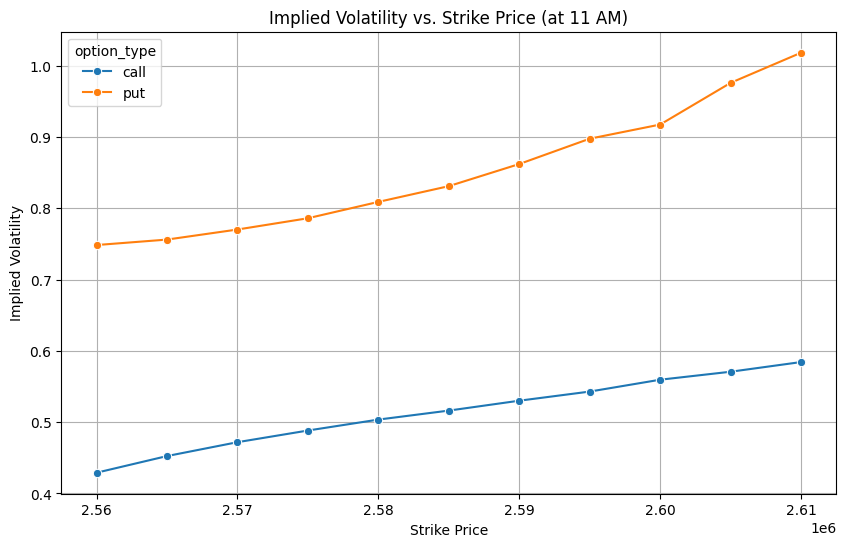

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike', y='implied_volatility', hue='option_type', marker='o')
plt.title('Implied Volatility vs. Strike Price (at 11 AM)')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.grid(True)
plt.show()

In [ ]:
if S is not None:
    options_df[['bs_price', 'delta', 'gamma', 'theta']] = options_df.apply(
        lambda row:
            pd.Series(black_scholes(
                S, row['strike'], row['T'], r, row['implied_volatility'], row['option_type']
            ))
        if row['T'] > 0 and not pd.isna(row['implied_volatility']) else pd.Series([np.nan, np.nan, np.nan, np.nan]), axis=1
    )
else:
    options_df[['bs_price', 'delta', 'gamma', 'theta']] = np.nan
    print("Cannot calculate Greeks as future price (S) is not available.")

display(options_df[['symbol', 'strike', 'option_type', 'last_trade_price', 'implied_volatility', 'delta', 'gamma', 'theta']].head())

,symbol,strike,option_type,last_trade_price,implied_volatility,delta,gamma,theta
2393,NIFTY2621025600CE,2560000.0,call,16790.0,0.429009,0.680472,0.000014,-8.787502e+06
2394,NIFTY2621025650CE,2565000.0,call,14115.0,0.452370,0.600615,0.000015,-9.990378e+06
2395,NIFTY2621025700CE,2570000.0,call,11770.0,0.471840,0.524993,0.000014,-1.072806e+07
2396,NIFTY2621025750CE,2575000.0,call,9725.0,0.488202,0.454317,0.000014,-1.103792e+07
2397,NIFTY2621025800CE,2580000.0,call,7990.0,0.503553,0.389375,0.000013,-1.100858e+07


Starting Delta Hedging Simulation for Call option with Strike 2570000.0 using Implied Volatility
Risk-free rate (r) = 0.05
Dataset contains 375 price points from 2026-02-05 09:16:00 to 2026-02-05 15:30:00.

--- Delta Hedging Results (using Implied Volatility) ---
Final Underlying Price (S_T): 2572000.00
Option Payoff at Expiry (-Z_T, from hedger's perspective): -2000.00
Cumulative Trading P&L from Delta Hedging: -4876.48
Total P&L from Delta Hedging (PL_T): -6876.48


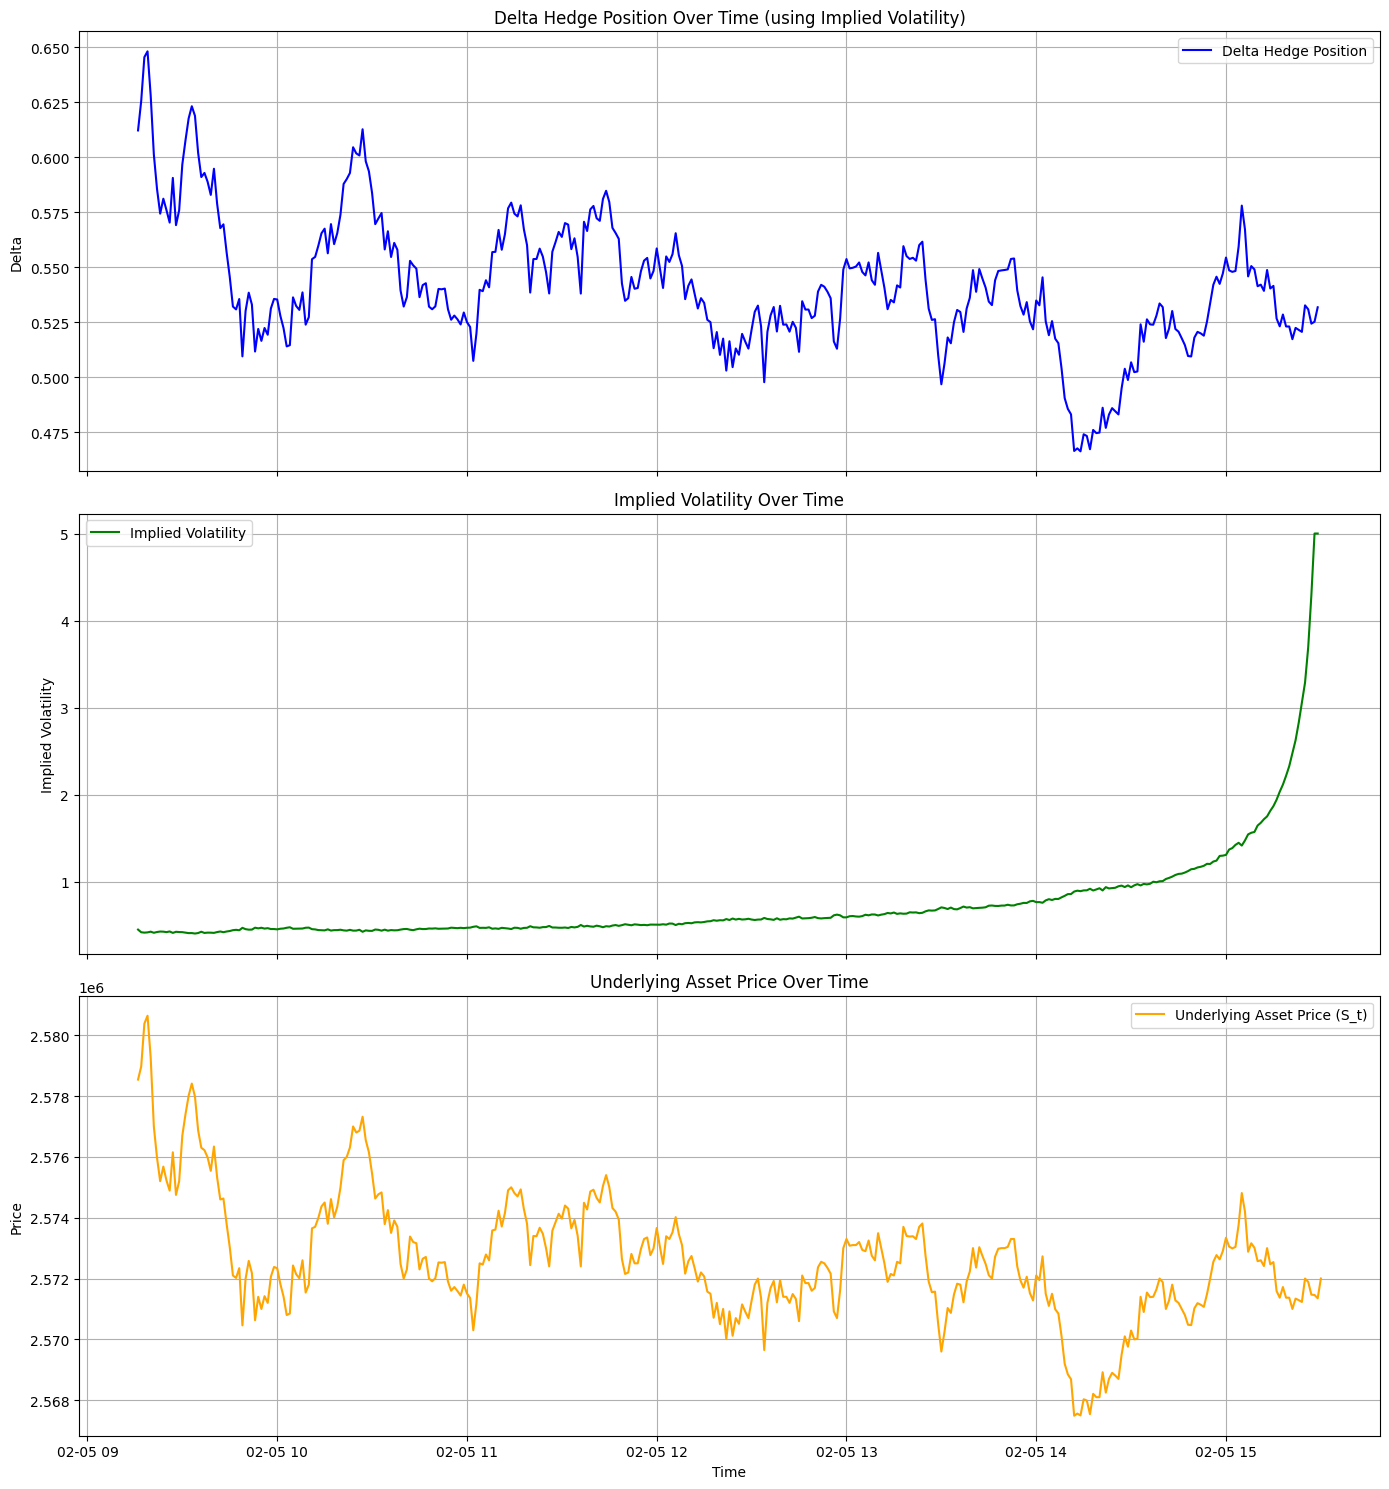

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# --- Black-Scholes function (assuming it's defined in a previous cell, included here for context) ---
def black_scholes(S, K, T, r, sigma, option_type):
    if T <= 0: # Handle zero or negative time to expiration
        if option_type == 'call':
            delta = 1.0 if S > K else 0.0
            return max(0, S - K), delta, 0, 0
        else:
            delta = -1.0 if S < K else 0.0
            return max(0, K - S), delta, 0, 0

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1) # Corrected put price formula
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price, delta, gamma, theta

# --- Implied Volatility solver (re-defined for clarity, assuming it's available from previous steps) ---
def implied_volatility(observed_price, S, K, T, r, option_type, tol=1e-5, max_iter=100):
    low_vol = 0.001
    high_vol = 5.0

    if T <= 0:
        return 0 # Or handle appropriately, e.g., NaN if IV is not applicable at expiry

    for i in range(max_iter):
        mid_vol = (low_vol + high_vol) / 2

        if mid_vol < 1e-6:
            mid_vol = 1e-6

        bs_price, _, _, _ = black_scholes(S, K, T, r, mid_vol, option_type)

        if abs(bs_price - observed_price) < tol:
            return mid_vol

        if bs_price < observed_price:
            low_vol = mid_vol
        else:
            high_vol = mid_vol

        if (high_vol - low_vol) < tol:
            return mid_vol

    return mid_vol # Return the best guess if max_iter reached

# --- Delta Hedging Implementation with Implied Volatility ---

# 1. Identify the target ATM option: NIFTY2621025700CE (Strike 2570000, Call)
target_strike = 2570000.0
target_option_type = 'call'
target_symbol_contains = 'NIFTY2621025700CE' # Specific symbol for the option

# Parameters for Black-Scholes and hedging
K = target_strike
r = 0.05 # Risk-free rate

# Prepare the full DataFrame for minute-by-minute simulation
df_iv_hedge = df_feb05.copy()

df_iv_hedge['observation_datetime_str'] = df_iv_hedge['date'].astype(str) + \
                                             df_iv_hedge['minute_end'].astype(str).str.zfill(6)
df_iv_hedge['observation_datetime'] = pd.to_datetime(df_iv_hedge['observation_datetime_str'], format='%Y%m%d%H%M%S')

# User specified expiration date and time: 0502 (Feb 5th) at 3:30 PM (15:30)
expiration_date = pd.to_datetime('2026-02-05 15:30:00')

# Get the time series data for future prices and the target option
future_prices_df = df_iv_hedge[df_iv_hedge['symbol'].str.contains('FUT')].copy()
option_prices_df = df_iv_hedge[df_iv_hedge['symbol'] == target_symbol_contains].copy()

# Merge them to ensure synchronized time steps
time_series_merged = pd.merge(future_prices_df, option_prices_df,
                              on='observation_datetime', suffixes=('_fut', '_opt'))
time_series_merged = time_series_merged.sort_values('observation_datetime').reset_index(drop=True)

# Calculate Time to Expiration (T) in years for each minute on the merged DataFrame
time_series_merged['T'] = (expiration_date - time_series_merged['observation_datetime']).dt.total_seconds() / (365.25 * 24 * 3600)

# Initialize hedging variables
cumulative_trading_pnl_iv_hedge = 0.0
delta_history_iv = []
iv_history = []
asset_price_history_iv = []

print(f"Starting Delta Hedging Simulation for {target_option_type.capitalize()} option with Strike {K} using Implied Volatility")
print(f"Risk-free rate (r) = {r}")

# Print information about the price points
num_price_points = len(time_series_merged)
first_timestamp = time_series_merged['observation_datetime'].min()
last_timestamp = time_series_merged['observation_datetime'].max()
print(f"Dataset contains {num_price_points} price points from {first_timestamp} to {last_timestamp}.")

# Loop through the time series data for delta hedging (up to the second to last minute)
for i in range(len(time_series_merged) - 1):
    S_ti = time_series_merged['last_trade_price_fut'].iloc[i]
    observed_option_price_ti = time_series_merged['last_trade_price_opt'].iloc[i]
    T_ti = time_series_merged['T'].iloc[i]

    # Calculate Implied Volatility at time t_i
    current_iv = implied_volatility(observed_option_price_ti, S_ti, K, T_ti, r, target_option_type)

    # If IV calculation fails or results in an invalid value, use a fallback (e.g., previous IV or a default)
    if pd.isna(current_iv) or current_iv <= 0:
        if iv_history: # Use previous IV if available
            current_iv = iv_history[-1]
        else: # Fallback to a default if no previous IV exists (e.g., initial fixed sigma)
            current_iv = 0.6 # This is similar to the fixed sigma in the previous step

    # Calculate delta at time t_i using Black-Scholes with the current implied volatility
    _, current_delta, _, _ = black_scholes(S_ti, K, T_ti, r, current_iv, target_option_type)

    delta_history_iv.append(current_delta)
    iv_history.append(current_iv)
    asset_price_history_iv.append(S_ti)

    # Get the price at the next minute (S_{ti+1})
    S_ti_plus_1 = time_series_merged['last_trade_price_fut'].iloc[i+1]

    # Contribution to P&L for this interval: delta_ti * (S_{ti+1} - S_ti)
    pnl_this_interval = current_delta * (S_ti_plus_1 - S_ti)
    cumulative_trading_pnl_iv_hedge += pnl_this_interval

# Final asset price at expiry (S_T is the last future price in the series)
S_T = time_series_merged['last_trade_price_fut'].iloc[-1]

# Calculate the option's payoff at expiry (Z_T) for the hedger (who sold the option)
if target_option_type == 'call':
    option_payoff_at_expiry = max(0, S_T - K)
elif target_option_type == 'put':
    option_payoff_at_expiry = max(0, K - S_T)
else:
    option_payoff_at_expiry = 0

# Calculate total PL_T using the provided formula (no transaction costs C_T(delta) = 0):
# PL_T = -Z_T + cumulative_trading_pnl - C_T(delta)
PL_T_iv_hedging = -option_payoff_at_expiry + cumulative_trading_pnl_iv_hedge

print(f"\n--- Delta Hedging Results (using Implied Volatility) ---")
print(f"Final Underlying Price (S_T): {S_T:.2f}")
print(f"Option Payoff at Expiry (-Z_T, from hedger's perspective): {-option_payoff_at_expiry:.2f}")
print(f"Cumulative Trading P&L from Delta Hedging: {cumulative_trading_pnl_iv_hedge:.2f}")
print(f"Total P&L from Delta Hedging (PL_T): {PL_T_iv_hedging:.2f}")

# --- Plotting the Delta, Implied Volatility, and Underlying Price ---
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# Plot 1: Delta Hedge Position
axes[0].plot(time_series_merged['observation_datetime'].iloc[:-1], delta_history_iv, label='Delta Hedge Position', color='blue')
axes[0].set_title('Delta Hedge Position Over Time (using Implied Volatility)')
axes[0].set_ylabel('Delta')
axes[0].grid(True)
axes[0].legend()

# Plot 2: Implied Volatility
axes[1].plot(time_series_merged['observation_datetime'].iloc[:-1], iv_history, label='Implied Volatility', color='green')
axes[1].set_title('Implied Volatility Over Time')
axes[1].set_ylabel('Implied Volatility')
axes[1].grid(True)
axes[1].legend()

# Plot 3: Underlying Asset Price
axes[2].plot(time_series_merged['observation_datetime'], time_series_merged['last_trade_price_fut'], label='Underlying Asset Price (S_t)', color='orange')
axes[2].set_title('Underlying Asset Price Over Time')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Price')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import time

# Parameters from our real market data
S0 = time_series_merged['last_trade_price_fut'].iloc[0]
num_steps = len(time_series_merged) - 1

time_diff = (time_series_merged['observation_datetime'].iloc[-1] - time_series_merged['observation_datetime'].iloc[0]).total_seconds()
T_total_years = time_diff / (365.25 * 24 * 3600)
dt = T_total_years / num_steps

base_iv = iv_history[0] if len(iv_history) > 0 else 0.3
sigma_lower_bound = max(0.05, base_iv - 0.1)
sigma_upper_bound = 0.8
mu = r = 0.05
num_paths = 100000
option_K = target_strike

print(f"Starting optimized generation for {num_paths} paths...")
start_time = time.time()

# -----------------------------------------------------------------
# PHASE 1: VECTORIZED GBM GENERATION
# -----------------------------------------------------------------
np.random.seed(42)

# Generate a (100000, 1) matrix of random volatilities
sigma_array = np.random.uniform(sigma_lower_bound, sigma_upper_bound, size=(num_paths, 1))
avgsigma = np.mean(sigma_array)

# Generate a (100000, 375) matrix of normal random variables
Z = np.random.normal(0, 1, size=(num_paths, num_steps))

# Calculate the drift and diffusion for the entire matrix
drift = (mu - 0.5 * sigma_array**2) * dt
diffusion = sigma_array * np.sqrt(dt) * Z

# Sum up the shocks over time and apply exponential
log_returns = np.cumsum(drift + diffusion, axis=1)
S_paths = S0 * np.exp(log_returns)

# Add S0 as the first column to make it (100000, 376)
S_0_column = np.full((num_paths, 1), S0)
synthetic_price_paths = np.hstack((S_0_column, S_paths))

gbm_time = time.time()
print(f"GBM Generation completed in {gbm_time - start_time:.2f} seconds.")

# -----------------------------------------------------------------
# PHASE 2: VECTORIZED BLACK-SCHOLES CALCULATION
# -----------------------------------------------------------------
# Create a time array (1, 376) that decreases from T_total_years to 0
T_array = T_total_years - (np.arange(num_steps + 1) * dt)
T_array = T_array.reshape(1, -1)

# Quant Trick: Replace exact 0.0 at the end with a tiny number (1e-8)
# to prevent division by zero errors in the Black-Scholes denominator.
T_array = np.where(T_array <= 0, 1e-8, T_array)

# Calculate d1 and d2 for the ENTIRE matrix at once
# S is (100000, 376), K is scalar, T is (1, 376), sigma is (100000, 1)
# Broadcasting handles the dimension matching automatically!
d1 = (np.log(synthetic_price_paths / option_K) + (r + 0.5 * sigma_array**2) * T_array) / (sigma_array * np.sqrt(T_array))
d2 = d1 - sigma_array * np.sqrt(T_array)

# Compute Prices and Deltas natively in C++ via SciPy/NumPy
all_bs_deltas = norm.cdf(d1)
all_bs_prices = synthetic_price_paths * all_bs_deltas - option_K * np.exp(-r * T_array) * norm.cdf(d2)

bs_time = time.time()
print(f"Black-Scholes completed in {bs_time - gbm_time:.2f} seconds.")
print(f"Total time: {bs_time - start_time:.2f} seconds.")

print(f"\nFinished calculating BS prices and deltas. Shape: {all_bs_prices.shape}")

Starting optimized generation for 100000 paths...
GBM Generation completed in 1.49 seconds.
Black-Scholes completed in 2.64 seconds.
Total time: 4.13 seconds.

Finished calculating BS prices and deltas. Shape: (100000, 375)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import LSTMCell, Dense

class LSTMHedger(tf.keras.Model):
    def __init__(self, units=32):
        super(LSTMHedger, self).__init__()
        # The LSTM cell handles the memory and recurrence
        self.lstm_cell = LSTMCell(units)
        # The Dense layer maps the LSTM output to a single Delta value
        self.output_layer = Dense(1, activation='tanh', name='delta_t_output')
    def call(self, inputs, states):
        """
        inputs: A tensor containing [S_t, BS_delta_t, delta_prev]
        states: A list of two tensors [h_prev, c_prev]
        """
        # Step the LSTM cell forward by one time step
        lstm_out, new_states = self.lstm_cell(inputs, states)

        # Convert the LSTM output into our Delta prediction
        predicted_delta = self.output_layer(lstm_out)

        return predicted_delta, new_states
num_lstm_units=32
lstm_deep_hedger=LSTMHedger(num_lstm_units)


2026-06-16 02:59:51.223949: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781578791.251884     107 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781578791.259829     107 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781578791.283890     107 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781578791.283935     107 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781578791.283938     107 computation_placer.cc:177] computation placer alr

In [ ]:
option_K = target_strike # Strike price (from previous real data analysis)
option_r = r             # Risk-free rate (from previous real data analysis)
option_type = 'call'     # Target option type


In [ ]:
from sklearn.model_selection import train_test_split

synthetic_price_paths_array = np.array(synthetic_price_paths)

test_size_ratio = 0.2

# Split the synthetic price paths
S_train, S_test = train_test_split(synthetic_price_paths_array, test_size=test_size_ratio, random_state=42)

# Split the corresponding Black-Scholes prices
BS_prices_train, BS_prices_test = train_test_split(all_bs_prices, test_size=test_size_ratio, random_state=42)

# Split the corresponding Black-Scholes deltas
BS_deltas_train, BS_deltas_test = train_test_split(all_bs_deltas, test_size=test_size_ratio, random_state=42)

print(f"Training set size: {len(S_train)} paths")
print(f"Test set size: {len(S_test)} paths")

print(f"Shape of S_train: {S_train.shape}")
print(f"Shape of BS_deltas_train: {BS_deltas_train.shape}")

Training set size: 80000 paths
Test set size: 20000 paths
Shape of S_train: (80000, 375)
Shape of BS_deltas_train: (80000, 375)


In [ ]:
batch_size = 1024
num_train_paths = S_train.shape[0]

train_dataset = tf.data.Dataset.from_tensor_slices(
    (S_train, BS_deltas_train)
).cache() \
 .shuffle(num_train_paths) \
 .batch(batch_size) \
 .prefetch(tf.data.AUTOTUNE)

print(f"Data pipeline created. Batch size: {batch_size}")

Data pipeline created. Batch size: 1024


## Intial training of model for convergence near black Scholes Model

In [ ]:
import tensorflow as tf
from tqdm.auto import tqdm
option_K_tf = tf.constant(option_K, dtype=tf.float32)
option_r_tf = tf.constant(option_r, dtype=tf.float32)
option_type_tf = tf.constant(option_type, dtype=tf.string)
num_time_steps=len(S_train[0])
optimizer_mse = tf.keras.optimizers.Adam(learning_rate=0.005) # Slightly higher LR for fast learning

@tf.function
def train_step_mse(batch_S_paths, batch_BS_deltas):
    batch_size_curr = tf.shape(batch_S_paths)[0]

    with tf.GradientTape() as tape:
        path_predicted_deltas_ta = tf.TensorArray(tf.float32, size=num_time_steps)
        delta_prev = tf.zeros((batch_size_curr, 1), dtype=tf.float32)

        h_prev = tf.zeros((batch_size_curr, 32), dtype=tf.float32)
        c_prev = tf.zeros((batch_size_curr, 32), dtype=tf.float32)
        states = [h_prev, c_prev]

        for t in tf.range(num_time_steps):
            S_t = tf.cast(tf.expand_dims(batch_S_paths[:, t], axis=-1), tf.float32)
            BS_delta_t = tf.cast(tf.expand_dims(batch_BS_deltas[:, t], axis=-1), tf.float32)
            S_t_normalized = S_t / option_K_tf
            comb_inp = tf.concat([S_t_normalized, BS_delta_t, delta_prev], axis=-1)
            predicted_delta_t, states = lstm_deep_hedger(comb_inp, states)

            path_predicted_deltas_ta = path_predicted_deltas_ta.write(t, predicted_delta_t)
            delta_prev = predicted_delta_t

        # Shape: (batch_size, num_time_steps)
        final_predicted_deltas = tf.squeeze(tf.transpose(path_predicted_deltas_ta.stack(), perm=[1, 0, 2]), axis=-1)

        loss = tf.reduce_mean(tf.square(final_predicted_deltas - tf.cast(batch_BS_deltas, tf.float32)))

    gradients = tape.gradient(loss, lstm_deep_hedger.trainable_variables)
    optimizer_mse.apply_gradients(zip(gradients, lstm_deep_hedger.trainable_variables))
    return loss

# 3. Train the model using MSE
epochs_mse = 7

print(f"Starting MSE Bootstrapping on {S_train.shape[0]} paths...")
for epoch in range(epochs_mse):
    epoch_loss_avg = tf.keras.metrics.Mean()
    batch_iterator = tqdm(train_dataset, desc=f"Epoch {epoch+1:02d}/{epochs_mse}", leave=True)

    for batch_S_paths, batch_BS_deltas in batch_iterator:
        loss = train_step_mse(batch_S_paths, batch_BS_deltas)
        epoch_loss_avg.update_state(loss)

        batch_iterator.set_postfix({"MSE Loss": f"{epoch_loss_avg.result().numpy():.6f}"})

print("MSE Bootstrapping Complete. The LSTM is now a cloned Black-Scholes model.")

In [ ]:
import os

# Define the file name
save_path = 'mse_pretrained_bs_weights.weights.h5'

# Save only the mathematical weights
lstm_deep_hedger.save_weights(save_path)

print(f"Success! MSE Bootstrapped weights saved to: {save_path}")

Success! MSE Bootstrapped weights saved to: mse_pretrained_bs_weights.weights.h5


In [ ]:
@tf.function
def calculate_pnl(S_path_batch, deltas_batch, K, r_tf, option_type_str, transaction_cost=0.001):
    S_path_batch = tf.cast(S_path_batch, tf.float32)
    deltas_batch = tf.cast(deltas_batch, tf.float32)
    K = tf.cast(K, tf.float32)

    # 1. Trading P&L
    price_changes = S_path_batch[:, 1:] - S_path_batch[:, :-1]
    trading_pnl_per_interval = deltas_batch[:, :-1] * price_changes
    cumulative_trading_pnl = tf.reduce_sum(trading_pnl_per_interval, axis=1)

    # 2. Transaction Costs
    initial_fee = transaction_cost * S_path_batch[:, 0] * tf.abs(deltas_batch[:, 0])

    delta_changes = tf.abs(deltas_batch[:, 1:] - deltas_batch[:, :-1])

    subsequent_fees = transaction_cost * S_path_batch[:, 1:] * delta_changes

    total_transaction_costs = initial_fee + tf.reduce_sum(subsequent_fees, axis=1)

    # 3. Option Payoff
    S_T = S_path_batch[:, -1]
    is_call = tf.cast(tf.strings.bytes_split(option_type_str)[0] == tf.constant(b'c'), tf.float32)
    option_payoff_at_expiry = tf.where(
        tf.cast(is_call, tf.bool),
        tf.maximum(0.0, S_T - K),
        tf.maximum(0.0, K - S_T)
    )

    # Total P&L minus transaction costs
    total_pnl = -option_payoff_at_expiry + cumulative_trading_pnl - total_transaction_costs
    return total_pnl
@tf.function
def cvar_loss(pnl_values, alpha=0.05):
    """
    Calculates the CVaR (Conditional Value at Risk) loss for a batch of P&L values.
    CVaR is the expected loss in the worst 'alpha' percentile.

    Args:
        pnl_values (tf.Tensor): A batch of P&L values (batch_size,).
        alpha (float): The significance level for CVaR (e.g., 0.05 for 5%).

    Returns:
        tf.Tensor: The CVaR loss (scalar).
    """
    # Sort P&L values in ascending order (from worst loss to best profit)
    sorted_pnl = tf.sort(pnl_values)

    # Calculate the index for VaR_alpha (worst 'alpha' percentage)
    num_samples = tf.cast(tf.shape(sorted_pnl)[0], tf.float32)
    cvar_index = tf.cast(tf.floor(num_samples * alpha), tf.int32)

    # Select the worst 'alpha' percentile of P&L values
    # Note: tf.slice is exclusive of the end index, so we need to go up to cvar_index
    worst_pnl_values = sorted_pnl[:cvar_index + 1] # Include up to the alpha-th percentile

    # CVaR is the negative of the average of these worst P&L values
    # We want to minimize the loss, so we minimize -CVaR or maximize CVaR.
    # Conventionally, CVaR is expressed as a positive loss, so we take the negative mean of P&L
    # PNL is profit, so minimizing average PNL means making profits smaller.
    # If PNL is negative (a loss), then -PNL is positive, and minimizing it means minimizing the loss.
    # So, CVaR loss will be -mean(worst_pnl_values)
    cvar_value = -tf.reduce_mean(worst_pnl_values)

    return cvar_value

print("TensorFlow-compatible P&L calculation and CVaR loss functions defined.")

TensorFlow-compatible P&L calculation and CVaR loss functions defined.


In [ ]:
# Use the global optimizer
optimizer_cvar = tf.keras.optimizers.Adam(learning_rate=0.001)

@tf.function
def train_step_cvar(batch_S_paths, batch_BS_deltas,transaction_cost=0):
    batch_size_curr = tf.shape(batch_S_paths)[0]

    with tf.GradientTape() as tape:
        path_predicted_deltas_ta = tf.TensorArray(tf.float32, size=num_time_steps)
        delta_prev = tf.zeros((batch_size_curr, 1), dtype=tf.float32)
        h_prev = tf.zeros((batch_size_curr, num_lstm_units), dtype=tf.float32)
        c_prev = tf.zeros((batch_size_curr, num_lstm_units), dtype=tf.float32)
        states = [h_prev, c_prev]

        for t in tf.range(num_time_steps):
            S_t = tf.cast(tf.expand_dims(batch_S_paths[:, t], axis=-1), tf.float32)
            BS_delta_t = tf.cast(tf.expand_dims(batch_BS_deltas[:, t], axis=-1), tf.float32)

            S_t_normalized = S_t / option_K_tf

            comb_inp = tf.concat([S_t_normalized, BS_delta_t, delta_prev], axis=-1)
            predicted_delta_t, states = lstm_deep_hedger(comb_inp, states)

            path_predicted_deltas_ta = path_predicted_deltas_ta.write(t, predicted_delta_t)
            delta_prev = predicted_delta_t

        final_predicted_deltas_seq = tf.transpose(path_predicted_deltas_ta.stack(), perm=[1, 0, 2])
        final_predicted_deltas_squeezed = tf.squeeze(final_predicted_deltas_seq, axis=-1)

        pnl_values = calculate_pnl(batch_S_paths, final_predicted_deltas_squeezed, option_K_tf, option_r_tf, option_type_tf,transaction_cost)
        loss = cvar_loss(pnl_values, alpha=0.05)

    gradients = tape.gradient(loss, lstm_deep_hedger.trainable_variables)
    optimizer_cvar.apply_gradients(zip(gradients, lstm_deep_hedger.trainable_variables))
    return loss


In [ ]:
epochs_cvar = 10
epoch_losses = []

print(f"Starting CVaR Deep Hedging on {S_train.shape[0]} paths...")

for epoch in range(epochs_cvar):
    epoch_loss_avg = tf.keras.metrics.Mean()

    batch_iterator = tqdm(train_dataset, desc=f"Epoch {epoch+1:02d}/{epochs_cvar}", leave=True)

    for batch_S_paths, batch_BS_deltas in batch_iterator:
        loss = train_step_cvar(batch_S_paths, batch_BS_deltas)
        epoch_loss_avg.update_state(loss)

        batch_iterator.set_postfix({"Live CVaR": f"{epoch_loss_avg.result().numpy():.0f}"})

    current_loss = epoch_loss_avg.result().numpy()
    epoch_losses.append(current_loss)


Starting CVaR Deep Hedging on 80000 paths...


Epoch 01/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 02/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 03/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 04/10:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 06/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 07/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 08/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 09/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/79 [00:00<?, ?it/s]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# ---------------------------------------------------------
# 1. Batched Inference Function (WITH NORMALIZATION)
# ---------------------------------------------------------
@tf.function
def predict_batch(model, batch_S, batch_BS, num_steps, K_tf):
    batch_size_curr = tf.shape(batch_S)[0]
    path_predicted_deltas_ta = tf.TensorArray(tf.float32, size=num_steps)

    delta_prev = tf.zeros((batch_size_curr, 1), dtype=tf.float32)

    num_lstm_units = model.lstm_cell.units
    h_prev = tf.zeros((batch_size_curr, num_lstm_units), dtype=tf.float32)
    c_prev = tf.zeros((batch_size_curr, num_lstm_units), dtype=tf.float32)
    states = [h_prev, c_prev]

    for t in tf.range(num_steps):
        S_t = tf.cast(tf.expand_dims(batch_S[:, t], axis=-1), tf.float32)
        BS_delta_t = tf.cast(tf.expand_dims(batch_BS[:, t], axis=-1), tf.float32)

        # ⚡️ THE FIX: Normalize the evaluation data exactly like the training data!
        S_t_normalized = S_t / K_tf

        comb_inp = tf.concat([S_t_normalized, BS_delta_t, delta_prev], axis=-1)
        predicted_delta_t, states = model(comb_inp, states)

        path_predicted_deltas_ta = path_predicted_deltas_ta.write(t, predicted_delta_t)
        delta_prev = predicted_delta_t

    final_seq = tf.transpose(path_predicted_deltas_ta.stack(), perm=[1, 0, 2])
    return tf.squeeze(final_seq, axis=-1)

def get_all_predictions(model, S_paths, BS_deltas, batch_size=1024):
    """Processes large datasets in batches to prevent GPU OOM crashes."""
    dataset = tf.data.Dataset.from_tensor_slices((S_paths, BS_deltas)).batch(batch_size)
    all_preds = []

    for batch_S, batch_BS in tqdm(dataset, desc="Predicting Deltas"):
        batch_pred = predict_batch(model, batch_S, batch_BS, num_time_steps, option_K_tf)
        all_preds.append(batch_pred)

    return tf.concat(all_preds, axis=0)

# ---------------------------------------------------------
# 2. Execute Predictions & Calculate P&L (FRICTIONLESS WORLD)
# ---------------------------------------------------------
# Set to 0.0 for Phase 1. Change to 0.001 for Phase 2!
current_tc = 0.0

print(f"\n--- Evaluating Train Set (Transaction Cost: {current_tc}) ---")
dh_preds_train = get_all_predictions(lstm_deep_hedger, S_train, BS_deltas_train)
dh_pnl_train = calculate_pnl(S_train, dh_preds_train, option_K_tf, option_r_tf, option_type_tf, current_tc).numpy()
bs_pnl_train = calculate_pnl(S_train, BS_deltas_train, option_K_tf, option_r_tf, option_type_tf, current_tc).numpy()

print(f"\n--- Evaluating Test Set (Transaction Cost: {current_tc}) ---")
dh_preds_test = get_all_predictions(lstm_deep_hedger, S_test, BS_deltas_test)
dh_pnl_test = calculate_pnl(S_test, dh_preds_test, option_K_tf, option_r_tf, option_type_tf, current_tc).numpy()
bs_pnl_test = calculate_pnl(S_test, BS_deltas_test, option_K_tf, option_r_tf, option_type_tf, current_tc).numpy()



=== FINAL PERFORMANCE METRICS ===
Deep Hedger (Train):
  Mean P&L:    -20405.34
  Std Dev:     3577.38
  VaR (5%):    -26143.84
  CVaR (5%):   27022.02

Black-Scholes (Train):
  Mean P&L:    -20410.25
  Std Dev:     3530.88
  VaR (5%):    -25987.86
  CVaR (5%):   26699.08

Deep Hedger (Test):
  Mean P&L:    -20423.68
  Std Dev:     3583.39
  VaR (5%):    -26154.08
  CVaR (5%):   27046.03

Black-Scholes (Test):
  Mean P&L:    -20423.08
  Std Dev:     3530.02
  VaR (5%):    -25987.65
  CVaR (5%):   26708.19



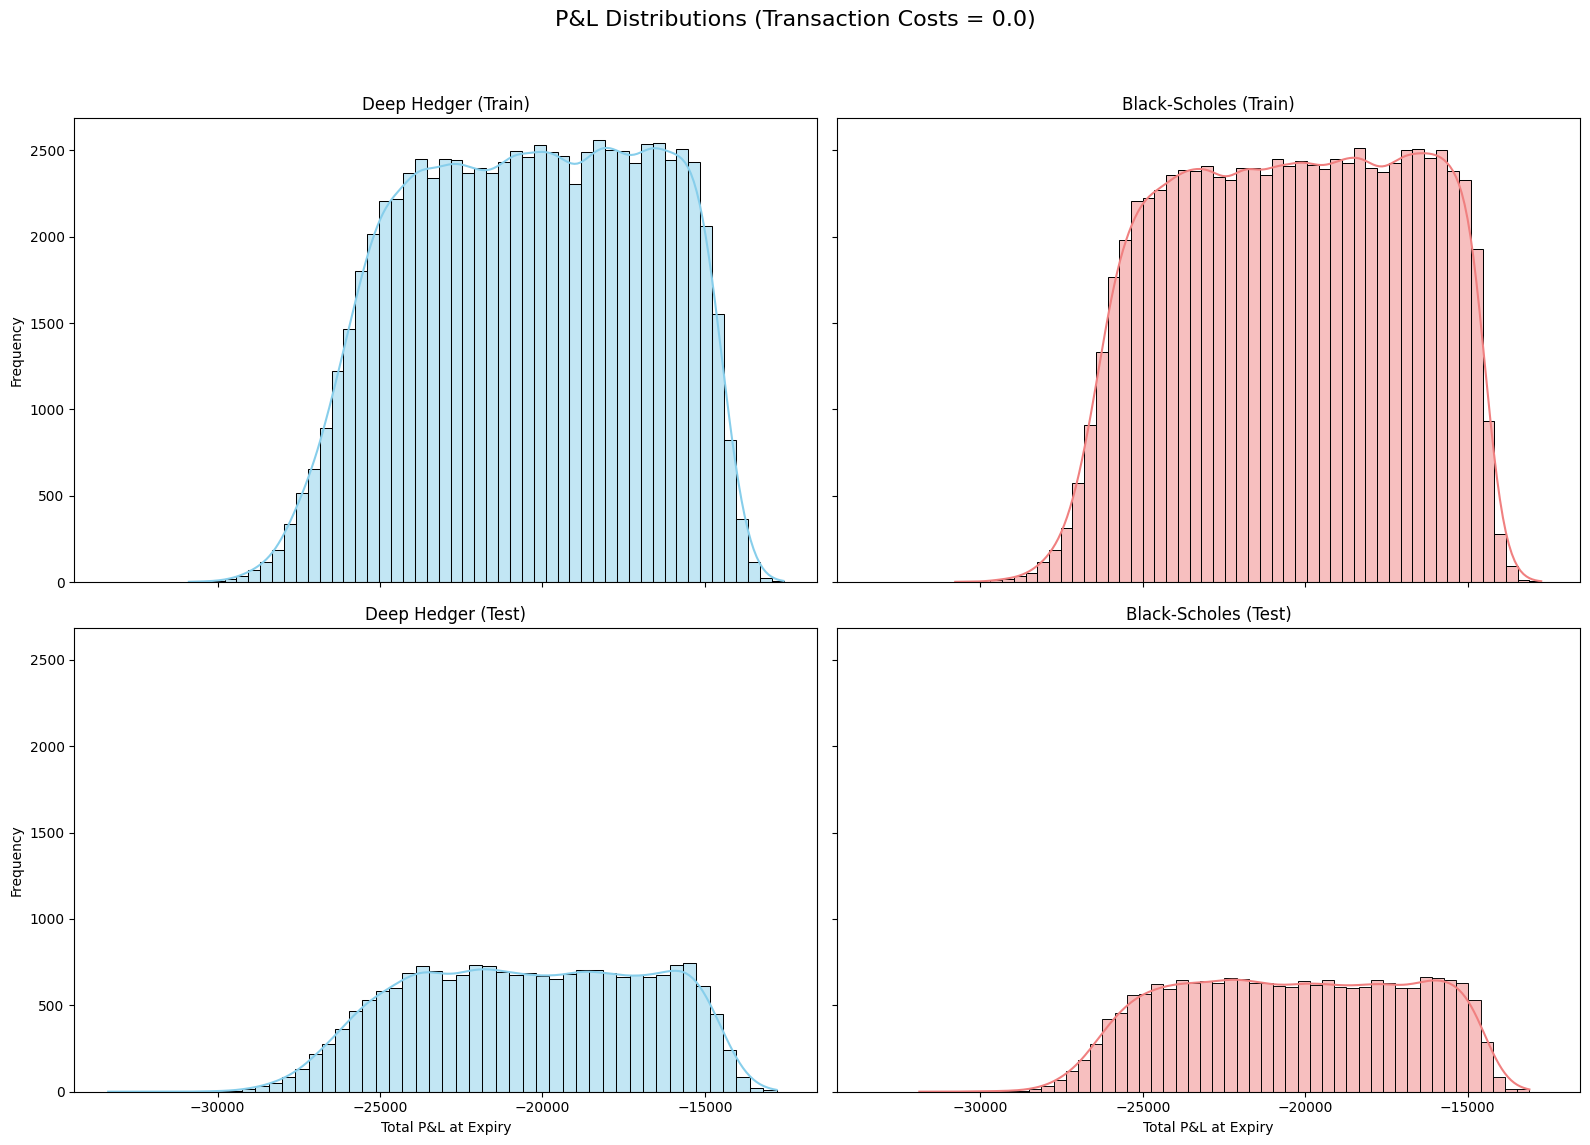

In [ ]:
def calculate_var(pnl_values, alpha=0.05):
    """
    Calculates Value at Risk (VaR) for a given set of P&L values.
    """
    pnl_values_sorted = np.sort(pnl_values)
    index = int(np.floor(len(pnl_values_sorted) * alpha))
    return pnl_values_sorted[index]

# Convert the tf.function cvar_loss to a numpy-compatible function for reporting
def calculate_cvar_numpy(pnl_values, alpha=0.05):
    return cvar_loss(tf.constant(pnl_values, dtype=tf.float32), alpha=alpha).numpy()


alph_level = 0.05

def print_metrics(name, pnl_data):
    mean_pnl = np.mean(pnl_data)
    std_pnl = np.std(pnl_data)
    var = calculate_var(pnl_data, alpha=alph_level)
    cvar = calculate_cvar_numpy(pnl_data, alpha=alph_level)

    print(f"{name}:")
    print(f"  Mean P&L:    {mean_pnl:.2f}")
    print(f"  Std Dev:     {std_pnl:.2f}")
    print(f"  VaR (5%):    {var:.2f}")
    print(f"  CVaR (5%):   {cvar:.2f}\n")

print("\n=== FINAL PERFORMANCE METRICS ===")
print_metrics("Deep Hedger (Train)", dh_pnl_train)
print_metrics("Black-Scholes (Train)", bs_pnl_train)
print_metrics("Deep Hedger (Test)", dh_pnl_test)
print_metrics("Black-Scholes (Test)", bs_pnl_test)

# ---------------------------------------------------------
# 4. Plot the P&L Distributions
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle(f'P&L Distributions (Transaction Costs = {current_tc})', fontsize=16)

# Histograms
sns.histplot(dh_pnl_train, bins=50, kde=True, ax=axes[0, 0], color='skyblue').set_title('Deep Hedger (Train)')
sns.histplot(bs_pnl_train, bins=50, kde=True, ax=axes[0, 1], color='lightcoral').set_title('Black-Scholes (Train)')
sns.histplot(dh_pnl_test,  bins=50, kde=True, ax=axes[1, 0], color='skyblue').set_title('Deep Hedger (Test)')
sns.histplot(bs_pnl_test,  bins=50, kde=True, ax=axes[1, 1], color='lightcoral').set_title('Black-Scholes (Test)')

for ax in axes.flat:
    ax.set_xlabel('Total P&L at Expiry')
    ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import tensorflow as tf
def get_bootstrap_model(model_path='mse_pretrained_bs_weights.weights.h5'):

    # 1. Create a fresh, empty model
    num_lstm_units = 32
    experiment_hedger = LSTMHedger(units=num_lstm_units)

    # 2. Create dummy data to initialize the mathematical graph
    # We use batch size 1, and 3 input features (S_t_normalized, BS_delta, delta_prev)
    dummy_inputs = tf.zeros((1, 3), dtype=tf.float32)
    dummy_h = tf.zeros((1, num_lstm_units), dtype=tf.float32)
    dummy_c = tf.zeros((1, num_lstm_units), dtype=tf.float32)
    dummy_states = [dummy_h, dummy_c]

    # 3. Pass the dummy data through the model ONCE
    _, _ = experiment_hedger(dummy_inputs, dummy_states)

    # 4. Load the saved weights into the initialized model
    experiment_hedger.load_weights(model_path)

    # print("Success! Pre-trained weights loaded. You are ready to experiment!")
    return experiment_hedger

In [ ]:
lstm_hedger_trans_cost=get_bootstrap_model()
# Use the global optimizer
optimizer_cvar_trans_cost = tf.keras.optimizers.Adam(learning_rate=0.001)

@tf.function
def train_step_cvar(batch_S_paths, batch_BS_deltas,model,optimizer_cvar,transaction_cost=0):
    batch_size_curr = tf.shape(batch_S_paths)[0]

    with tf.GradientTape() as tape:
        path_predicted_deltas_ta = tf.TensorArray(tf.float32, size=num_time_steps)
        delta_prev = tf.zeros((batch_size_curr, 1), dtype=tf.float32)
        h_prev = tf.zeros((batch_size_curr, num_lstm_units), dtype=tf.float32)
        c_prev = tf.zeros((batch_size_curr, num_lstm_units), dtype=tf.float32)
        states = [h_prev, c_prev]

        for t in tf.range(num_time_steps):
            S_t = tf.cast(tf.expand_dims(batch_S_paths[:, t], axis=-1), tf.float32)
            BS_delta_t = tf.cast(tf.expand_dims(batch_BS_deltas[:, t], axis=-1), tf.float32)

            S_t_normalized = S_t / option_K_tf

            comb_inp = tf.concat([S_t_normalized, BS_delta_t, delta_prev], axis=-1)
            predicted_delta_t, states = model(comb_inp, states)

            path_predicted_deltas_ta = path_predicted_deltas_ta.write(t, predicted_delta_t)
            delta_prev = predicted_delta_t

        final_predicted_deltas_seq = tf.transpose(path_predicted_deltas_ta.stack(), perm=[1, 0, 2])
        final_predicted_deltas_squeezed = tf.squeeze(final_predicted_deltas_seq, axis=-1)

        pnl_values = calculate_pnl(batch_S_paths, final_predicted_deltas_squeezed, option_K_tf, option_r_tf, option_type_tf,transaction_cost)
        loss = cvar_loss(pnl_values, alpha=0.05)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer_cvar.apply_gradients(zip(gradients, model.trainable_variables))
    return loss


In [ ]:
from tqdm import tqdm
epochs_cvar = 10
epoch_losses = []


print(f"Starting CVaR Deep Hedging on {S_train.shape[0]} paths...")

for epoch in range(epochs_cvar):
    epoch_loss_avg = tf.keras.metrics.Mean()

    batch_iterator = tqdm(train_dataset, desc=f"Epoch {epoch+1:02d}/{epochs_cvar}", leave=True)

    for batch_S_paths, batch_BS_deltas in batch_iterator:
        loss = train_step_cvar(
            batch_S_paths,
            batch_BS_deltas,
            model=lstm_hedger_trans_cost,
            optimizer_cvar=optimizer_cvar_trans_cost,
            transaction_cost=0.0015
        )
        epoch_loss_avg.update_state(loss)

        batch_iterator.set_postfix({"Live CVaR": f"{epoch_loss_avg.result().numpy():.0f}"})

    current_loss = epoch_loss_avg.result().numpy()
    epoch_losses.append(current_loss)

Starting CVaR Deep Hedging on 80000 paths...


Epoch 10/10: 100%|██████████| 79/79 [00:42<00:00,  1.85it/s, Live CVaR=36683]


In [ ]:
import os

# Define the file name
save_path = 'lstm_trans_cost_trained.weights.h5'

# Save only the mathematical weights
lstm_hedger_trans_cost.save_weights(save_path)

print(f"Success! MSE Bootstrapped weights saved to: {save_path}")

Success! MSE Bootstrapped weights saved to: lstm_trans_cost_trained.weights.h5


In [ ]:
# Helper function
def get_all_predictions(model, S_paths, BS_deltas, batch_size=1024):
    """Processes large datasets in batches to prevent GPU OOM crashes."""
    dataset = tf.data.Dataset.from_tensor_slices((S_paths, BS_deltas)).batch(batch_size)
    all_preds = []

    for batch_S, batch_BS in tqdm(dataset, desc="Predicting Deltas"):
        batch_pred = predict_batch(model, batch_S, batch_BS, num_time_steps, option_K_tf)
        all_preds.append(batch_pred)

    return tf.concat(all_preds, axis=0)





def calculate_var(pnl_values, alpha=0.05):
    """
    Calculates Value at Risk (VaR) for a given set of P&L values.
    """
    pnl_values_sorted = np.sort(pnl_values)
    index = int(np.floor(len(pnl_values_sorted) * alpha))
    return pnl_values_sorted[index]

# Convert the tf.function cvar_loss to a numpy-compatible function for reporting
def calculate_cvar_numpy(pnl_values, alpha=0.05):
    return cvar_loss(tf.constant(pnl_values, dtype=tf.float32), alpha=alpha).numpy()


alph_level = 0.05

def print_metrics(name, pnl_data):
    mean_pnl = np.mean(pnl_data)
    std_pnl = np.std(pnl_data)
    var = calculate_var(pnl_data, alpha=alph_level)
    cvar = calculate_cvar_numpy(pnl_data, alpha=alph_level)

    print(f"{name}:")
    print(f"  Mean P&L:    {mean_pnl:.2f}")
    print(f"  Std Dev:     {std_pnl:.2f}")
    print(f"  VaR (5%):    {var:.2f}")
    print(f"  CVaR (5%):   {cvar:.2f}\n")


Predicting Deltas:   0%|          | 0/79 [00:00<?, ?it/s]

Predicting Deltas:   0%|          | 0/20 [00:00<?, ?it/s]

Deep Hedger (Train):
  Mean P&L:    -27152.56
  Std Dev:     4371.85
  VaR (5%):    -34747.34
  CVaR (5%):   36593.84

Black-Scholes (Train):
  Mean P&L:    -45937.09
  Std Dev:     10001.96
  VaR (5%):    -62501.50
  CVaR (5%):   65657.80

Deep Hedger (Test):
  Mean P&L:    -27173.47
  Std Dev:     4379.96
  VaR (5%):    -34761.72
  CVaR (5%):   36660.95

Black-Scholes (Test):
  Mean P&L:    -46028.08
  Std Dev:     10007.19
  VaR (5%):    -62415.70
  CVaR (5%):   65693.11



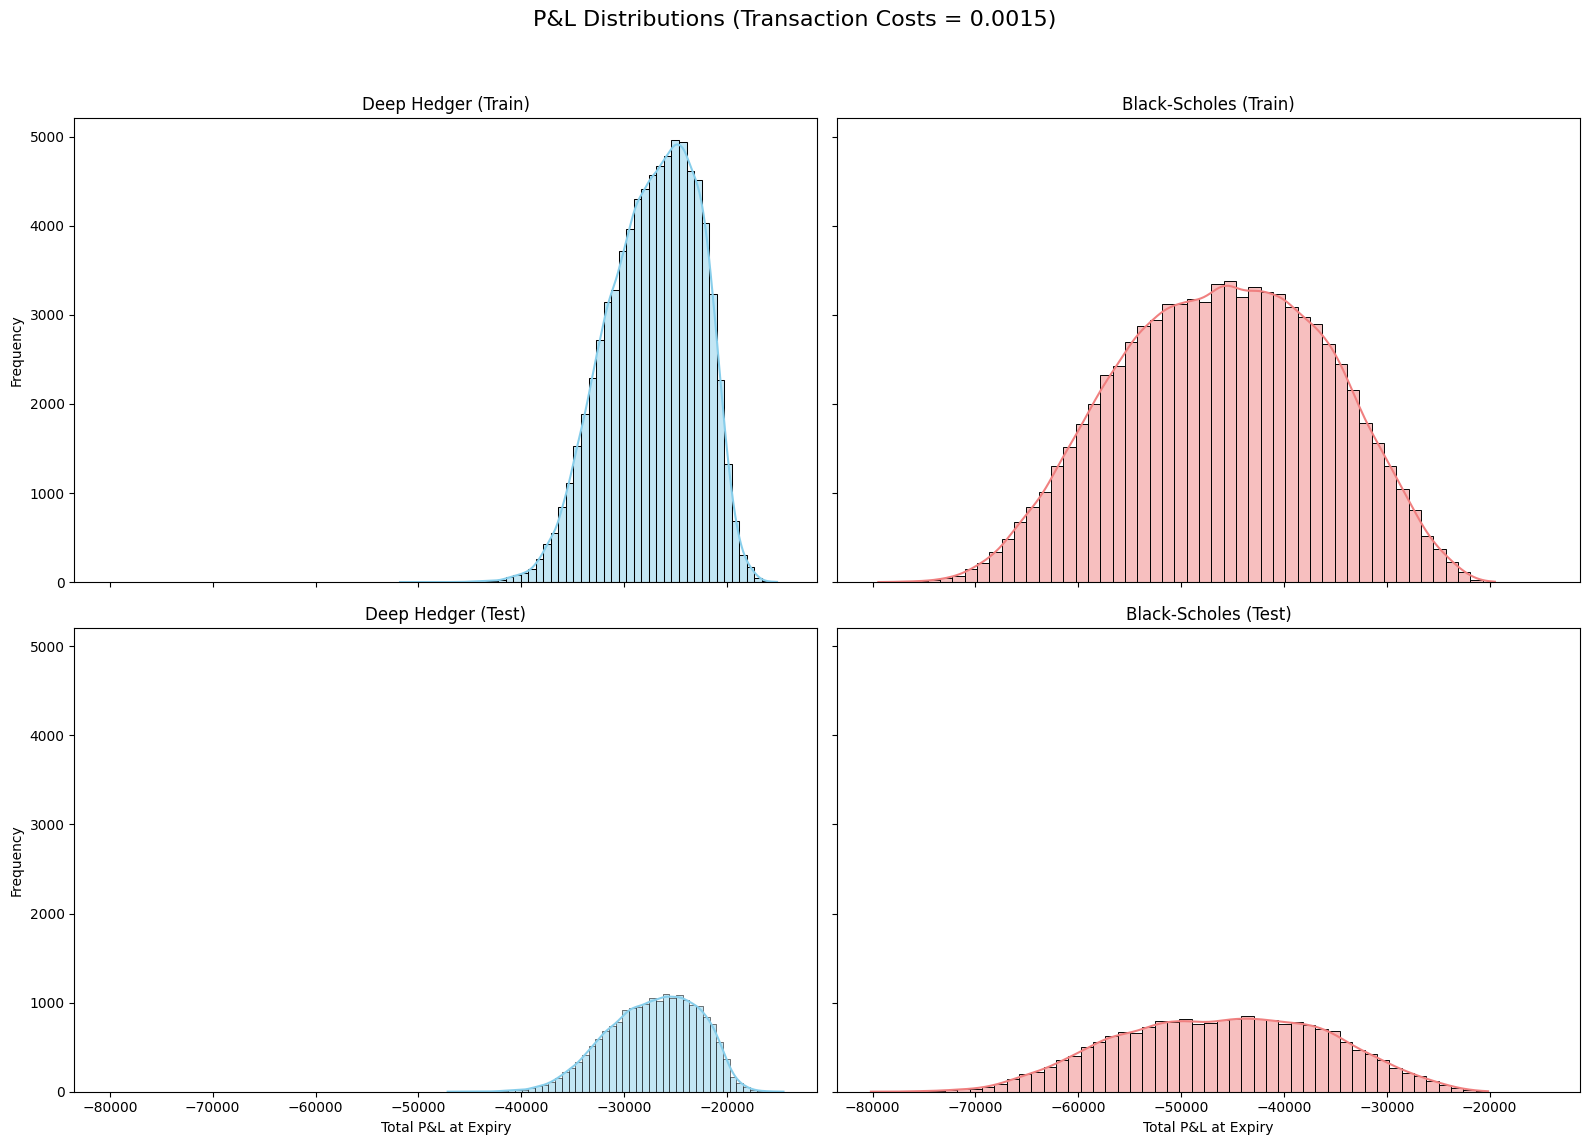

In [ ]:
lstm_hedger_trans_cost=get_bootstrap_model('lstm_trans_cost_trained.weights.h5')
current_tc=0.0015
dh_preds_train = get_all_predictions(lstm_hedger_trans_cost, S_train, BS_deltas_train)
dh_pnl_train = calculate_pnl(S_train, dh_preds_train, option_K_tf, option_r_tf, option_type_tf, current_tc).numpy()
bs_pnl_train = calculate_pnl(S_train, BS_deltas_train, option_K_tf, option_r_tf, option_type_tf, current_tc).numpy()
dh_preds_test = get_all_predictions(lstm_hedger_trans_cost, S_test, BS_deltas_test)
dh_pnl_test = calculate_pnl(S_test, dh_preds_test, option_K_tf, option_r_tf, option_type_tf, current_tc).numpy()
bs_pnl_test = calculate_pnl(S_test, BS_deltas_test, option_K_tf, option_r_tf, option_type_tf, current_tc).numpy()
print_metrics("Deep Hedger (Train)", dh_pnl_train)
print_metrics("Black-Scholes (Train)", bs_pnl_train)
print_metrics("Deep Hedger (Test)", dh_pnl_test)
print_metrics("Black-Scholes (Test)", bs_pnl_test)
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle(f'P&L Distributions (Transaction Costs = {current_tc})', fontsize=16)

# Histograms
sns.histplot(dh_pnl_train, bins=50, kde=True, ax=axes[0, 0], color='skyblue').set_title('Deep Hedger (Train)')
sns.histplot(bs_pnl_train, bins=50, kde=True, ax=axes[0, 1], color='lightcoral').set_title('Black-Scholes (Train)')
sns.histplot(dh_pnl_test,  bins=50, kde=True, ax=axes[1, 0], color='skyblue').set_title('Deep Hedger (Test)')
sns.histplot(bs_pnl_test,  bins=50, kde=True, ax=axes[1, 1], color='lightcoral').set_title('Black-Scholes (Test)')

for ax in axes.flat:
    ax.set_xlabel('Total P&L at Expiry')
    ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Hooraay!!!!
The Deep Hedger model succesfully beat the black scholes model in the real world where transaction costs are significant.**This is the real use case of neural networks** that is they can adopt to situations where mathematical models are used as a starting point.

**Next Steps**
* Backtest the current model on real world option pricing data(To evaluate the value of current model)
* Train GAN model for generating price paths-(Going in a direction of research paper)


=== REAL WORLD BACKTEST RESULTS (FEB 05) ===
Black-Scholes Real P&L: -19826.21
Deep Hedger Real P&L:   -9978.26
Net Advantage:          9847.95 Rupees


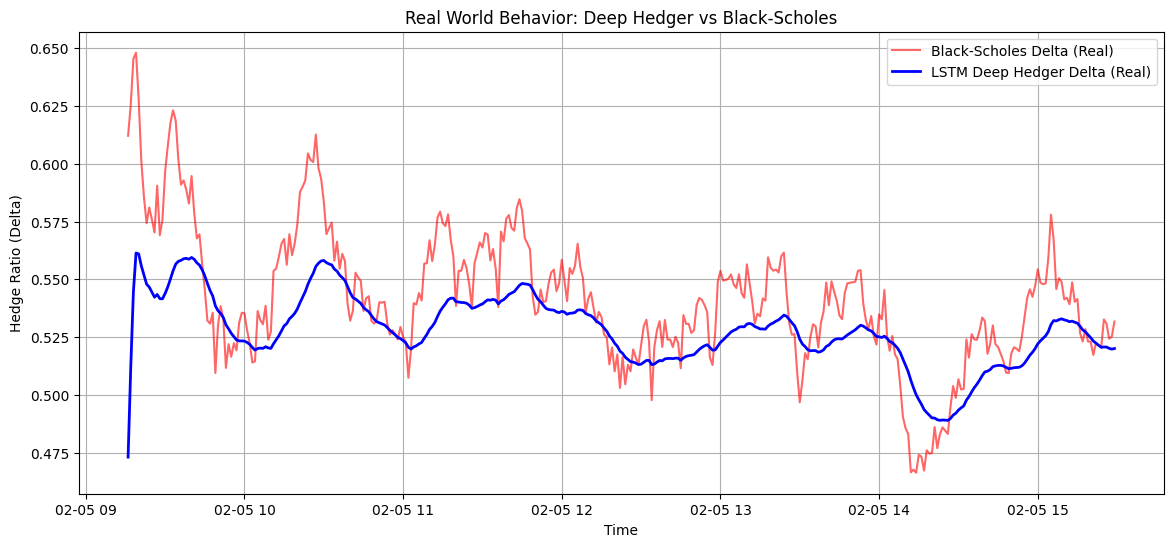

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def run_real_world_backtest(trained_model, real_S_series, real_BS_deltas, K, r, option_type, transaction_cost=0.0015):
    """
    Runs a trained Deep Hedger on a single, real-world historical price path.
    """
    # 1. Format the real data
    # real_S_series has 375 points. num_steps for hedging intervals is 374.
    num_steps = len(real_S_series) - 1

    # Ensure we use exactly num_steps for deltas
    real_S_path = np.array(real_S_series[:-1]).reshape(1, num_steps)
    # real_BS_deltas is already length 374 from the previous cells
    real_BS_deltas_arr = np.array(real_BS_deltas[:num_steps]).reshape(1, num_steps)

    # Final price for Payoff
    S_T = real_S_series.iloc[-1]

    K_tf = tf.constant(K, dtype=tf.float32)
    delta_prev = tf.zeros((1, 1), dtype=tf.float32)
    num_lstm_units = trained_model.lstm_cell.units
    h_prev = tf.zeros((1, num_lstm_units), dtype=tf.float32)
    c_prev = tf.zeros((1, num_lstm_units), dtype=tf.float32)
    states = [h_prev, c_prev]

    lstm_predicted_deltas = []

    # 2. Step through the day
    for t in range(num_steps):
        S_t = tf.cast(tf.expand_dims(real_S_path[:, t], axis=-1), tf.float32)
        BS_delta_t = tf.cast(tf.expand_dims(real_BS_deltas_arr[:, t], axis=-1), tf.float32)

        S_t_normalized = S_t / K_tf
        comb_inp = tf.concat([S_t_normalized, BS_delta_t, delta_prev], axis=-1)
        predicted_delta_t, states = trained_model(comb_inp, states)

        lstm_predicted_deltas.append(predicted_delta_t.numpy()[0][0])
        delta_prev = predicted_delta_t

    # Reshape LSTM deltas to (1, 374)
    lstm_predicted_deltas_arr = np.array(lstm_predicted_deltas).reshape(1, num_steps)

    # Prepare full path for P&L (375 points total: S_0 to S_T)
    full_S_path_tf = tf.constant(np.append(real_S_path.flatten(), S_T).reshape(1, num_steps + 1), dtype=tf.float32)

    # Pad deltas to match full_S_path length (375) so that [:, :-1] in calculate_pnl works correctly
    lstm_deltas_padded = np.hstack([lstm_predicted_deltas_arr, [[lstm_predicted_deltas_arr[0, -1]]]])
    bs_deltas_padded = np.hstack([real_BS_deltas_arr, [[real_BS_deltas_arr[0, -1]]]])

    lstm_deltas_tf = tf.constant(lstm_deltas_padded, dtype=tf.float32)
    bs_deltas_tf = tf.constant(bs_deltas_padded, dtype=tf.float32)

    # Calculate P&L
    lstm_pnl = calculate_pnl(full_S_path_tf, lstm_deltas_tf, K, r, option_type, transaction_cost).numpy()[0]
    bs_pnl = calculate_pnl(full_S_path_tf, bs_deltas_tf, K, r, option_type, transaction_cost).numpy()[0]

    return lstm_predicted_deltas_arr.flatten(), lstm_pnl, bs_pnl

real_prices = time_series_merged['last_trade_price_fut']
real_bs_deltas = delta_history_iv

lstm_real_deltas, lstm_real_pnl, bs_real_pnl = run_real_world_backtest(
    lstm_hedger_trans_cost,
    real_prices,
    real_bs_deltas,
    target_strike,
    r,
    'call',
    transaction_cost=0.0015
)

print("\n=== REAL WORLD BACKTEST RESULTS (FEB 05) ===")
print(f"Black-Scholes Real P&L: {bs_real_pnl:.2f}")
print(f"Deep Hedger Real P&L:   {lstm_real_pnl:.2f}")
print(f"Net Advantage:          {lstm_real_pnl - bs_real_pnl:.2f}")

plt.figure(figsize=(14, 6))
plt.plot(time_series_merged['observation_datetime'].iloc[:-1], real_bs_deltas, label='Black-Scholes Delta (Real)', color='red', alpha=0.6)
plt.plot(time_series_merged['observation_datetime'].iloc[:-1], lstm_real_deltas, label='LSTM Deep Hedger Delta (Real)', color='blue', linewidth=2)
plt.title('Real World Behavior: Deep Hedger vs Black-Scholes')
plt.ylabel('Hedge Ratio (Delta)')
plt.xlabel('Time')
plt.legend()
plt.grid(True)
plt.show()

**Observation** We can see clearly that lstm deep hedger hedging ration is continuos which tells that deep hedger model is acknowledged the transaction costs and trades less frequently and hedges by keeping the transaction cost in mind